# Fraud Operations Analysis

## D1 — Load data and quick data quality check

In this section we:
- load the dataset
- inspect structure
- check missing values
- compute the fraud rate

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
df = pd.read_csv("creditcard.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [21]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [22]:
fraud_counts = df['Class'].value_counts()

total_rows = len(df)
fraud_count = fraud_counts[1]
fraud_rate = fraud_count / total_rows

print("Total transactions:", total_rows)
print("Fraud transactions:", fraud_count)
print("Fraud rate:", fraud_rate)

Total transactions: 284807
Fraud transactions: 492
Fraud rate: 0.001727485630620034


## D2 — Fraud rate by transaction amount

Fraud transactions may be more common in certain transaction size ranges.  
We analyze fraud rate across transaction amount buckets.

In [23]:
import pandas as pd
df['amount_bucket'] = pd.qcut(df['Amount'], 10)

In [24]:
fraud_by_bucket = (
    df.groupby('amount_bucket')['Class']
      .agg(['count', 'sum', 'mean'])
      .rename(columns={
          'count': 'transactions',
          'sum': 'frauds',
          'mean': 'fraud_rate'
      })
)

fraud_by_bucket

/tmp/ipykernel_378/710821369.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('amount_bucket')['Class']


,transactions,frauds,fraud_rate
amount_bucket,,,
"(-0.001, 1.0]",30492,181,0.005936
"(1.0, 3.57]",26473,27,0.001020
"(3.57, 8.91]",28559,36,0.001261
"(8.91, 13.0]",28405,13,0.000458
"(13.0, 22.0]",28714,14,0.000488
"(22.0, 37.0]",28375,17,0.000599
"(37.0, 59.8]",28366,24,0.000846
"(59.8, 100.0]",28915,50,0.001729
"(100.0, 203.0]",28050,45,0.001604


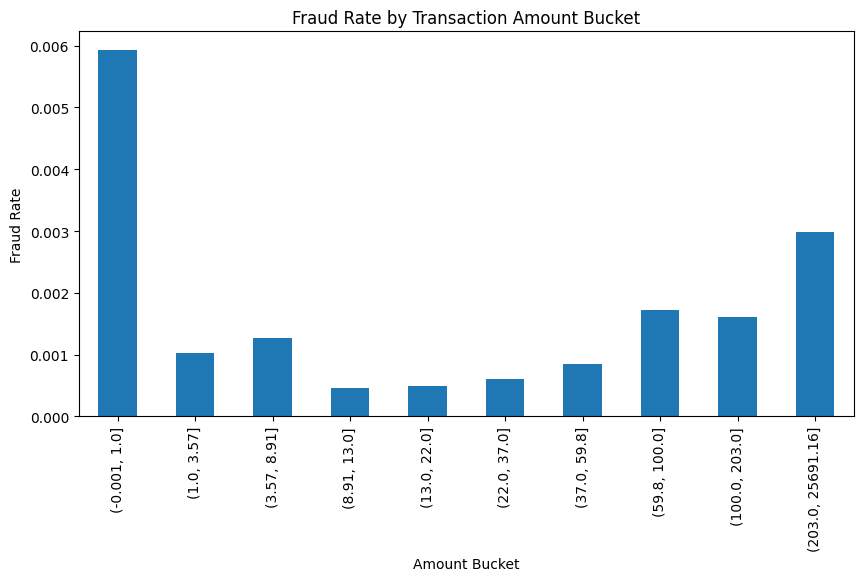

In [25]:
fraud_by_bucket['fraud_rate'].plot(
    kind='bar',
    figsize=(10,5),
    title='Fraud Rate by Transaction Amount Bucket'
)

plt.ylabel("Fraud Rate")
plt.xlabel("Amount Bucket")
plt.show()

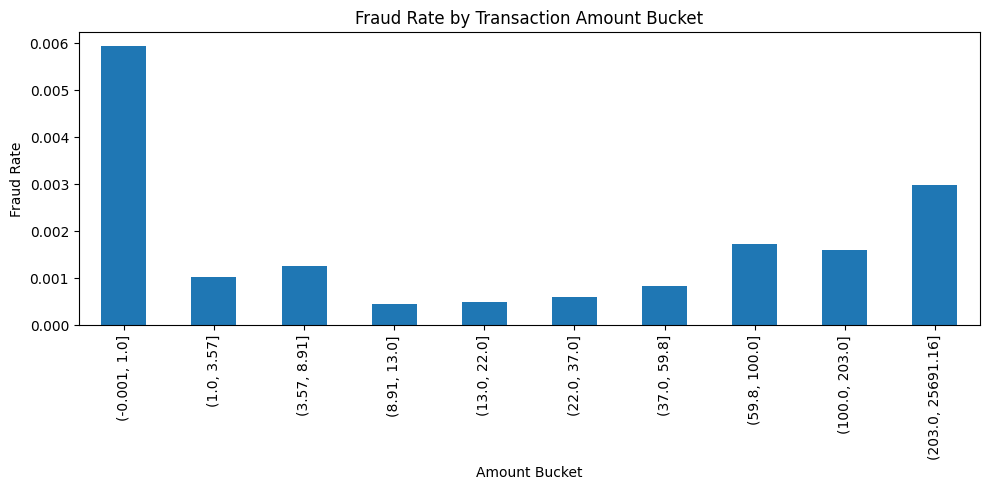

In [26]:
plt.figure(figsize=(10,5))
fraud_by_bucket['fraud_rate'].plot(kind='bar')

plt.title("Fraud Rate by Transaction Amount Bucket")
plt.ylabel("Fraud Rate")
plt.xlabel("Amount Bucket")

plt.tight_layout()
plt.savefig("fraud_rate_by_amount.png")

### Insight

Fraud rate is significantly higher in the smallest transaction amount bucket.

This suggests that fraudulent transactions are more likely to occur at low amounts.  
One possible explanation is that fraudsters attempt small transactions first to test whether a stolen card is active and to avoid triggering fraud detection rules.

Operational implication: monitoring systems may benefit from increased scrutiny of repeated small transactions.

## D3 — Fraud activity by hour

We analyze whether fraud transactions occur more frequently during certain hours.

In [27]:
df['hour'] = (df['Time'] // 3600) % 24

In [28]:
fraud_by_hour = (
    df.groupby('hour')['Class']
      .agg(['count','sum','mean'])
      .rename(columns={
          'count':'transactions',
          'sum':'frauds',
          'mean':'fraud_rate'
      })
)

fraud_by_hour

,transactions,frauds,fraud_rate
hour,,,
0.0,7695,6,0.000780
1.0,4220,10,0.002370
2.0,3328,57,0.017127
3.0,3492,17,0.004868
4.0,2209,23,0.010412
5.0,2990,11,0.003679
6.0,4101,9,0.002195
7.0,7243,23,0.003175
8.0,10276,9,0.000876


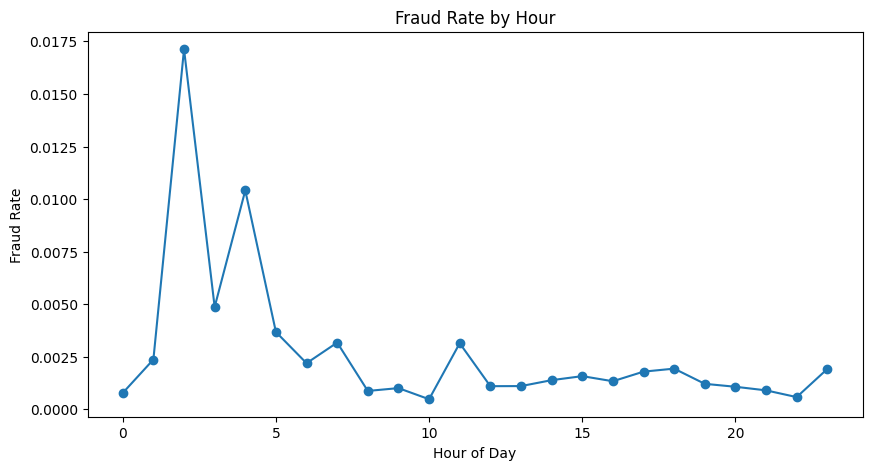

In [29]:
fraud_by_hour['fraud_rate'].plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    title='Fraud Rate by Hour'
)

plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate")
plt.show()

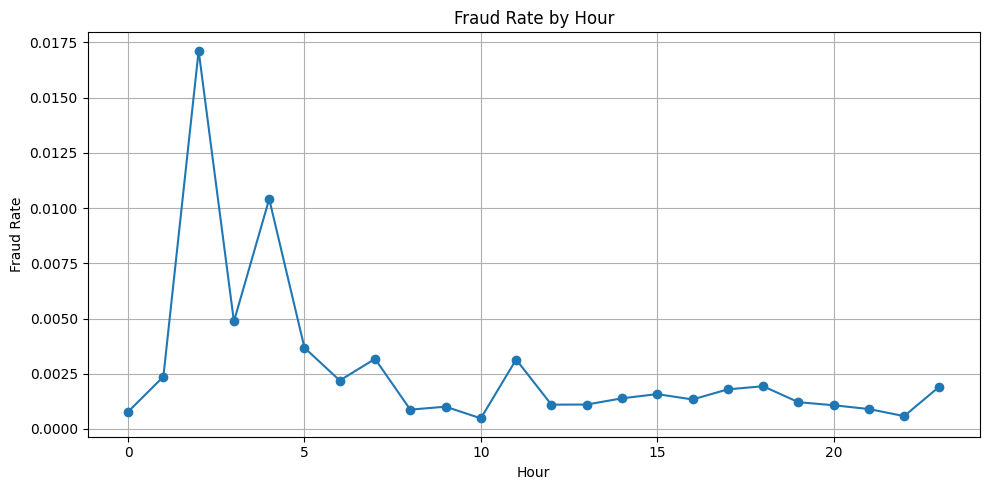

In [30]:
plt.figure(figsize=(10,5))

fraud_by_hour['fraud_rate'].plot(
    kind='line',
    marker='o'
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.grid(True)

plt.tight_layout()
plt.savefig("fraud_rate_by_hour.png")

## D4 — Rapid repeated transactions

Fraudulent activity sometimes occurs as a burst of transactions within very short time intervals.
We analyze the time difference between consecutive transactions.

In [31]:
df = df.sort_values(['Time'])

df['prev_time'] = df.groupby('Class')['Time'].shift(1)

df['seconds_since_last'] = df['Time'] - df['prev_time']

In [32]:
df.groupby('Class')['seconds_since_last'].mean()

,seconds_since_last
Class,
0,0.607751
1,346.114053


In [33]:
df[df['seconds_since_last'] < 60]['Class'].value_counts()

,count
Class,
0,284314
1,183


Fraudulent transactions tend to occur in rapid succession.
Transactions occurring within short time intervals may indicate automated fraud attempts.

### Insight

Fraud activity peaks during early hours of the transaction timeline (around hour 2).

Although the dataset timestamp represents seconds since the first recorded transaction rather than absolute clock time, the pattern suggests that fraud attempts cluster during certain low-activity periods.

## D3 — Fraud activity by hour

We analyze whether fraud transactions occur more frequently during certain hours of the day.